## **NETFLIX CONTENT ANALYSIS & RECOMMENDATION SYSTEM**

End-to-end data analysis and machine learning project to derive insights and build recommendation capabilities.

## BUSINESS CONTEXT

***This dataset consists of TV shows and movies available on Netflix as of 2019, sourced from Flixable, a third-party Netflix search engine. Industry trends indicate that since 2010, the number of TV shows on Netflix has significantly increased, while the number of movies has declined.***

***This shift suggests a strategic transition in Netflix’s content focus toward episodic content. Analyzing this dataset helps in understanding content distribution, genre trends, and regional availability.***

***Such insights can support data-driven decisions related to content production, acquisition, and platform strategy.***


## PROBLEM STATEMENT

***The goal of this project is to analyze Netflix's content dataset to uncover patterns in content distribution, genre trends, and release behavior. Additionally, this project aims to build machine learning models to classify content and develop a recommendation system to suggest similar content to users.***

## BUSINESS OBJECTIVES

1. Analyze the distribution of Movies vs TV Shows
2. Identify trends in content addition over the years
3. Determine the most popular genres on Netflix
4. Analyze content availability across different countries
5. Build a machine learning model to classify content type
6. Develop a recommendation system to improve user engagement

## Data Loading & Initial Inspection 

In [1]:

# IMPORT LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
# LOAD DATA WITH ERROR HANDLING

df = pd.read_csv('../data/netflix.csv')
 

In [3]:
# BASIC DATA INSPECTION 

print("Shape of dataset:", df.shape)

df.head()

Shape of dataset: (7787, 12)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...


In [4]:
# DATA INFO

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       7787 non-null   object
 1   type          7787 non-null   object
 2   title         7787 non-null   object
 3   director      5398 non-null   object
 4   cast          7069 non-null   object
 5   country       7280 non-null   object
 6   date_added    7777 non-null   object
 7   release_year  7787 non-null   int64 
 8   rating        7780 non-null   object
 9   duration      7787 non-null   object
 10  listed_in     7787 non-null   object
 11  description   7787 non-null   object
dtypes: int64(1), object(11)
memory usage: 730.2+ KB


In [5]:
# STATISTICAL SUMMARY

df.describe(include='all')

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,7787,7787,7787,5398,7069,7280,7777,7787.000000,7780,7787,7787,7787
unique,7787,2,7787,4049,6831,681,1565,NaN,14,216,492,7769
top,s7787,Movie,ZZ TOP: THAT LITTLE OL' BAND FROM TEXAS,"Raúl Campos, Jan Suter",David Attenborough,United States,"January 1, 2020",NaN,TV-MA,1 Season,Documentaries,Multiple women report their husbands as missin...
freq,1,5377,1,18,18,2555,118,NaN,2863,1608,334,3
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.932580,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.757395,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018.000000,NaN,NaN,NaN,NaN


## DATASET DESCRIPTION

| Column Name  | Description              |
| ------------ | ------------------------ |
| show_id      | Unique ID for each title |
| type         | Movie or TV Show         |
| title        | Name of the content      |
| director     | Director of the content  |
| cast         | Actors involved          |
| country      | Country of production    |
| date_added   | Date added to Netflix    |
| release_year | Year of release          |
| rating       | Age rating               |
| duration     | Length (minutes/seasons) |
| listed_in    | Genre/category           |
| description  | Summary of content       |


## WHY WE ARE DOING THIS

# Why data inspection?
- To understand:
    - Number of rows & columns
    - Data types
    - Missing values
    - Potential issues before cleaning

# Business Impact:
- Wrong understanding here → wrong model later
- Garbage in → garbage out (this is real, not theory)

## Data Cleaning & Preprocessing

In [6]:
# CHECK MISSING VALUES

df.isnull().sum().sort_values(ascending=False)

director        2389
cast             718
country          507
date_added        10
rating             7
title              0
show_id            0
type               0
release_year       0
duration           0
listed_in          0
description        0
dtype: int64

***When we leave gaps in our data, we aren't just missing numbers; we’re missing the context that makes a story complete. In the world of Netflix, every empty "director" or "cast" cell is a missed connection between a creator and an audience, while a missing "country" tag can lead a business to steer its strategy toward the wrong region entirely. By cleaning up these holes, we ensure our models don’t just process data—they actually understand the nuances of the people and places behind the screen, leading to sharper insights and recommendations that actually feel human.***

In [7]:
# HANDLING MISSING VALUES

df['director'].fillna('Unknown', inplace=True)
df['cast'].fillna('Unknown', inplace=True)
df['country'].fillna('Unknown', inplace=True)
df['rating'].fillna('Unknown', inplace=True)

df.dropna(subset=['date_added'], inplace=True)

***By labeling text as "Unknown," we preserve the bulk of our data for analysis without inventing false details. For vital columns like "date_added," we remove the gaps entirely to ensure our business timelines stay accurate and free from guesswork.***

- Smart Retention: "Unknown" tags keep the dataset whole so we don't lose rows that still have valuable genre or title info.

- Reliable Timelines: Removing rows with missing dates prevents "ghost" data from polluting your seasonal trends and launch insights.

In [8]:
# REMOVE DUPLICATES

df.duplicated().sum()

df.drop_duplicates(inplace=True)
df.shape

(7777, 12)

***Duplicates act like echoes that distort the truth, making certain trends seem more significant than they really are. By clearing them out, you ensure your analysis is based on unique facts rather than accidental repetitions, keeping your models sharp and your business insights honest.***

In [9]:
# FIXING THE DATA TYPES

df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

df = df.dropna(subset=['date_added'])


# Enables time-based analysis
# Required for trends

In [10]:
# CREATING NEW FEATURES 

df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

# Helps in trend analysis
# Important for EDA + ML

In [11]:
# CLEANING THE DURATION COLUMN 

df['duration_num'] = df['duration'].str.extract('(\d+)')
df['duration_num'] = pd.to_numeric(df['duration_num'])

# ML models need numeric values
# Text duration is useless for modeling

In [12]:
df.isnull().sum()


show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
year_added      0
month_added     0
duration_num    0
dtype: int64

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7689 entries, 0 to 7786
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       7689 non-null   object        
 1   type          7689 non-null   object        
 2   title         7689 non-null   object        
 3   director      7689 non-null   object        
 4   cast          7689 non-null   object        
 5   country       7689 non-null   object        
 6   date_added    7689 non-null   datetime64[ns]
 7   release_year  7689 non-null   int64         
 8   rating        7689 non-null   object        
 9   duration      7689 non-null   object        
 10  listed_in     7689 non-null   object        
 11  description   7689 non-null   object        
 12  year_added    7689 non-null   int32         
 13  month_added   7689 non-null   int32         
 14  duration_num  7689 non-null   int64         
dtypes: datetime64[ns](1), int32(2), int64(2), o

In [14]:
df.value_counts

<bound method DataFrame.value_counts of      show_id     type                                    title  \
0         s1  TV Show                                       3%   
1         s2    Movie                                     7:19   
2         s3    Movie                                    23:59   
3         s4    Movie                                        9   
4         s5    Movie                                       21   
...      ...      ...                                      ...   
7782   s7783    Movie                                     Zozo   
7783   s7784    Movie                                   Zubaan   
7784   s7785    Movie                        Zulu Man in Japan   
7785   s7786  TV Show                    Zumbo's Just Desserts   
7786   s7787    Movie  ZZ TOP: THAT LITTLE OL' BAND FROM TEXAS   

               director                                               cast  \
0               Unknown  João Miguel, Bianca Comparato, Michel Gomes, R...   
1     Jorge

## EXPLORATORY DATA ANALYSIS (EDA)

# Univariate Analysis

In [15]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description',
       'year_added', 'month_added', 'duration_num'],
      dtype='object')

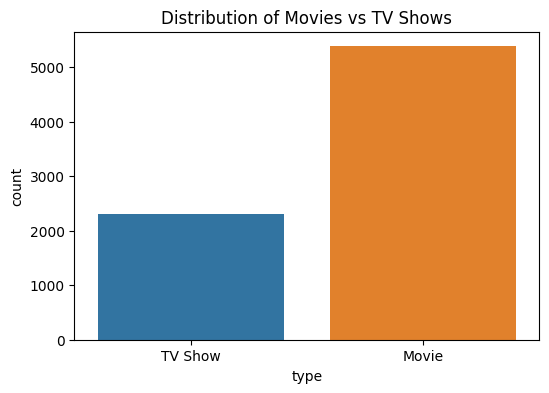

In [16]:
# CHART 1 : DISTRIBUTION OF CONTENT TYPE 
plt.figure(figsize=(6,4))
sns.countplot(x='type', data=df, hue="type")
plt.title("Distribution of Movies vs TV Shows")
plt.show()

# 1. Why this chart?
Countplot is best for analyzing a single categorical variable

# 2. Insight
Identify whether Movies or TV Shows dominate

# 3. Business Impact
- Helps Netflix understand content distribution strategy
- If one dominates → imbalance in content offering

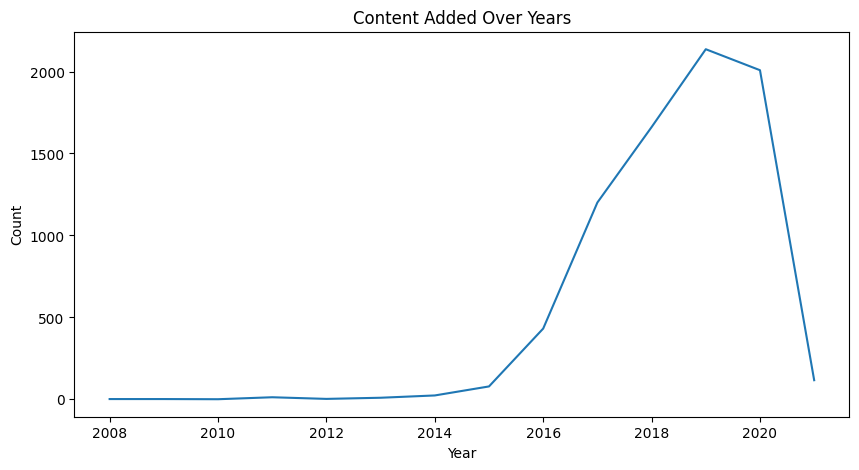

In [17]:
# CHART 2: CONTENT ADDED OVER YEARS 

plt.figure(figsize=(10,5))
df['year_added'].value_counts().sort_index().plot(kind='line')
plt.title("Content Added Over Years")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

# 1. Why this chart?
Line chart is best for trend analysis over time
# 2. Insight
Growth pattern of Netflix content
# 3. Business Impact
Shows expansion phases
Helps identify scaling strategy

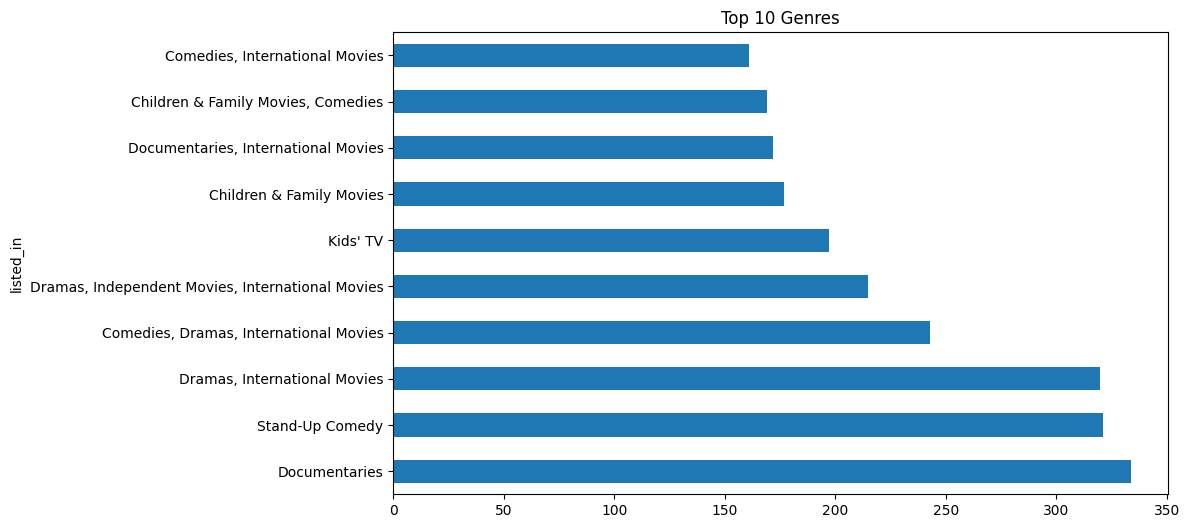

In [18]:
#CHART 3 :  TOP 10 GENRES

plt.figure(figsize=(10,6))
df['listed_in'].value_counts().head(10).plot(kind='barh')
plt.title("Top 10 Genres")
plt.show()

❓ Why this chart?
Horizontal bar improves readability for multiple categories
🧠 Insight
Most popular genres on Netflix
💼 Business Impact
Helps decide what type of content to invest in

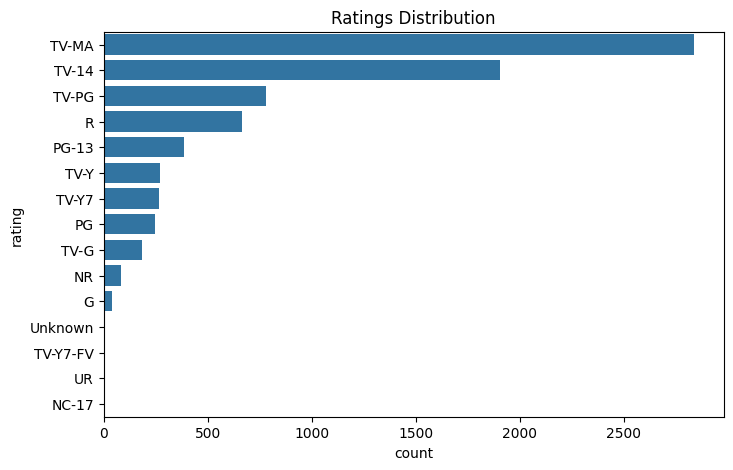

In [19]:
# CHART 4: RATINGS DISTRIBUTION 
plt.figure(figsize=(8,5))
sns.countplot(y='rating', data=df, order=df['rating'].value_counts().index)
plt.title("Ratings Distribution")
plt.show()

❓ Why?
Shows categorical frequency clearly
🧠 Insight
Which audience group Netflix targets most
💼 Business Impact
Helps align content with audience demographics

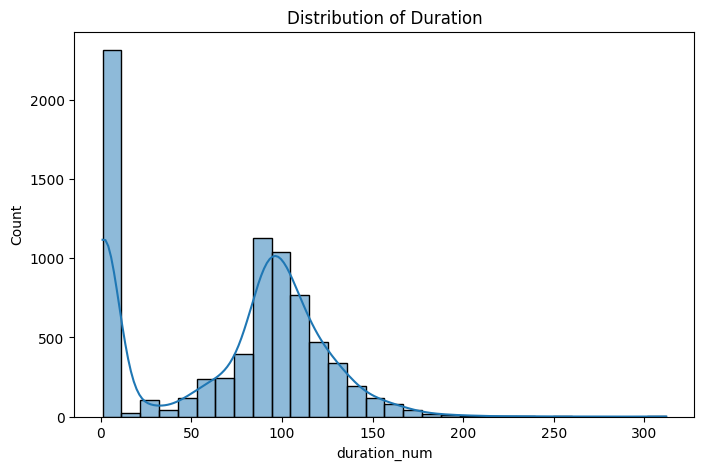

In [20]:
#CHART 5: DURATION DISTRIBUTION 

plt.figure(figsize=(8,5))
sns.histplot(df['duration_num'], bins=30, kde=True)
plt.title("Distribution of Duration")
plt.show()

❓ Why?
Histogram shows distribution of numerical variable
🧠 Insight
Most common content length
💼 Business Impact
Helps optimize content length for engagement

BIVARIATE ANALYSIS

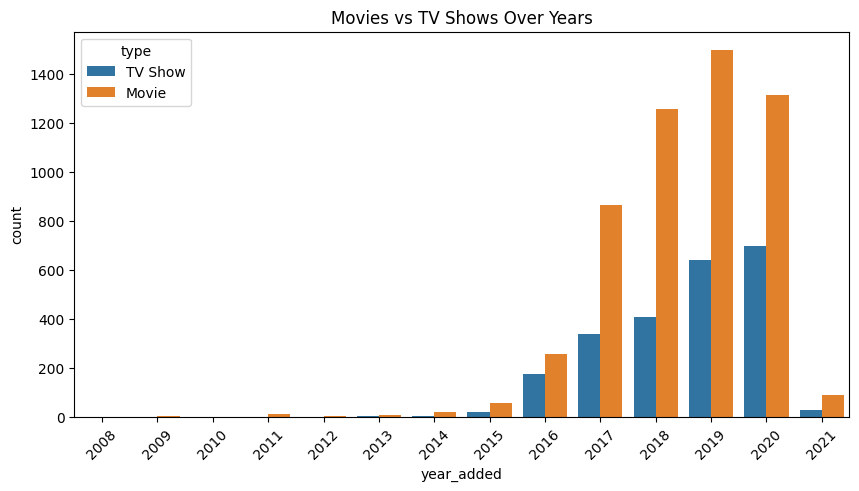

In [21]:
# CHART 6: CONTENT TYPE VS YEAR

plt.figure(figsize=(10,5))
sns.countplot(x='year_added', hue='type', data=df)
plt.xticks(rotation=45)
plt.title("Movies vs TV Shows Over Years")
plt.show()

## Why this chart?

We used this to see how Netflix’s content strategy has changed over time—especially whether they are focusing more on movies or TV shows.

## Insight

Over the years, movies were dominant initially, but TV shows started increasing significantly after around 2015.

## Business Impact 

This tells us Netflix is shifting towards TV shows, likely because series keep users engaged for longer periods.
If users spend more time on the platform, retention improves—which is critical for subscription-based businesses.

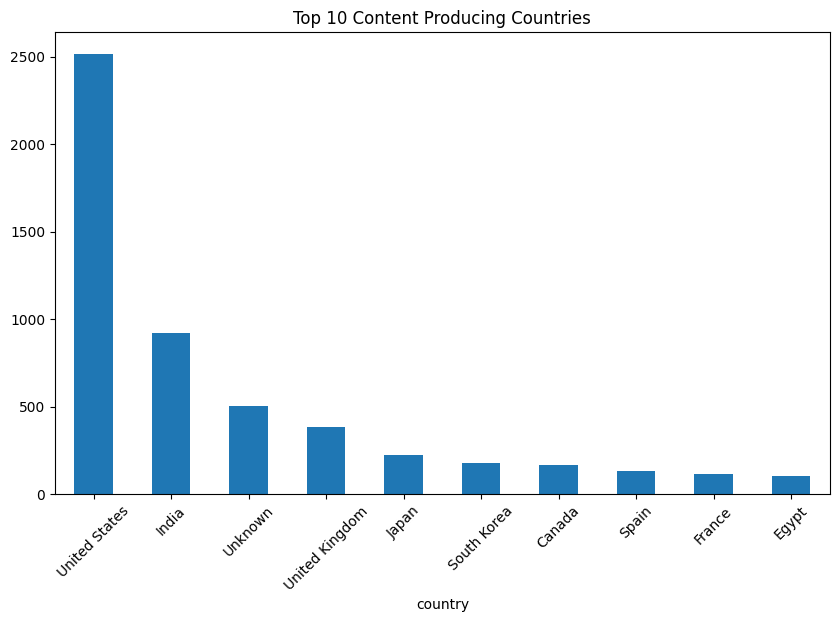

In [22]:
# CHART 7 : TOP COUNTRIES PRODUCING CONTENT 

plt.figure(figsize=(10,6))
df['country'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Content Producing Countries")
plt.xticks(rotation=45)
plt.show()

## Why this chart?

To understand which countries contribute the most content to Netflix.

## Insight

The United States dominates content production, followed by countries like India and the UK.

## Business Impact

This shows where Netflix has strong production partnerships.
At the same time, it highlights opportunities—if some regions are underrepresented, Netflix can expand there to attract new audiences.

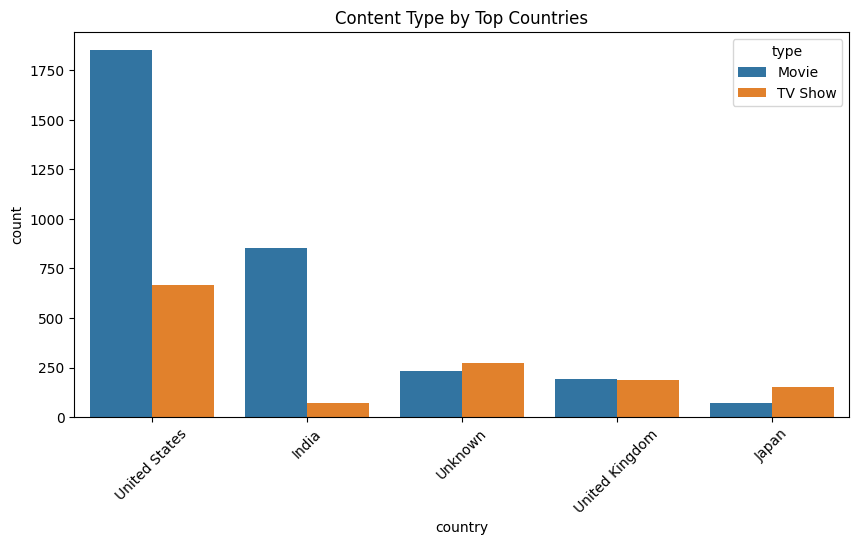

In [23]:
# CHART 8: CONTENT TYPE BY COUNTRY

top_countries = df['country'].value_counts().head(5).index

plt.figure(figsize=(10,5))
sns.countplot(x='country', hue='type', data=df[df['country'].isin(top_countries)])
plt.title("Content Type by Top Countries")
plt.xticks(rotation=45)
plt.show()

# Why this chart?

To see whether different countries focus more on movies or TV shows.

# Insight

Some countries mainly produce movies, while others are contributing more TV shows.

# Business Impact

This helps Netflix customize its strategy region-wise.
For example, if a country produces strong TV content, Netflix can invest more in series there instead of movies.

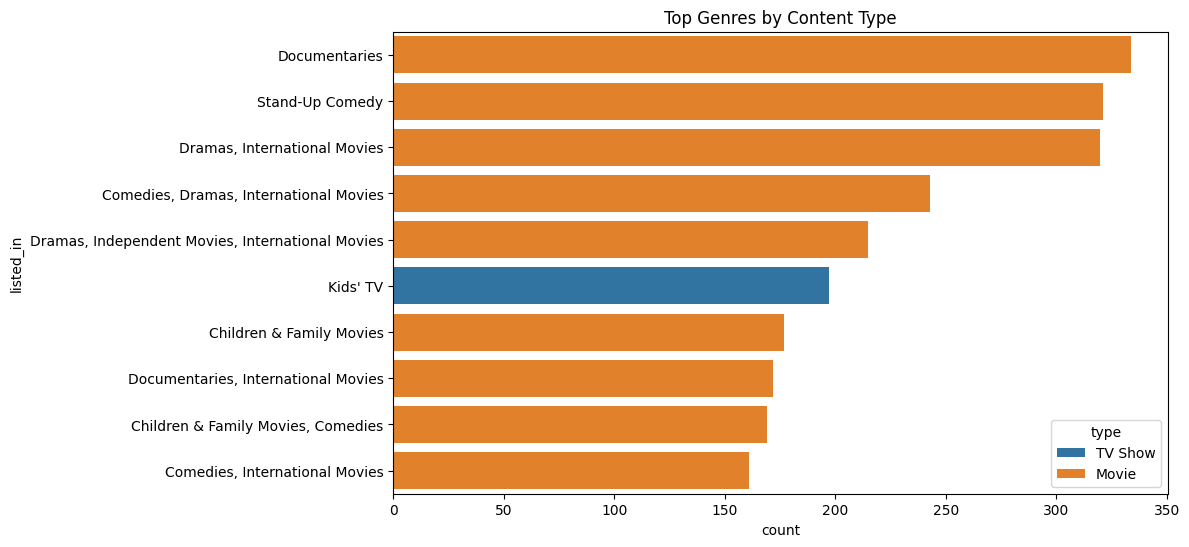

In [24]:
#CHART 9: GENRE VS CONTENT TYPE

plt.figure(figsize=(10,6))
sns.countplot(y='listed_in', hue='type', 
            data=df, 
            order=df['listed_in'].value_counts().index[:10])
plt.title("Top Genres by Content Type")
plt.show()

# Why this chart?

To understand how different genres are distributed between movies and TV shows.

# Insight

Certain genres like Drama and Comedy dominate across both, but some genres are more common in either movies or shows.

# Business Impact

This helps Netflix decide what type of content to produce within each genre.
For example, if a genre performs better as a series, they should prioritize TV shows over movies in that category.

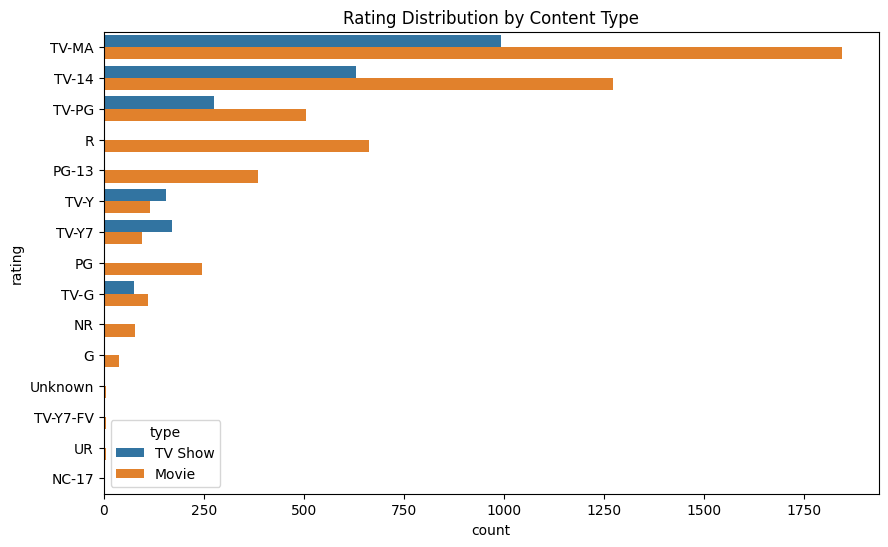

In [25]:
# CHART 10 - RATING VS TYPE


plt.figure(figsize=(10,6))
sns.countplot(y='rating', hue='type', 
            data=df, 
            order=df['rating'].value_counts().index)
plt.title("Rating Distribution by Content Type")
plt.show()

# Why this chart?

To understand which audience groups (kids, adults, etc.) are targeted by movies vs TV shows.

# Insight

Different ratings are more common in movies vs TV shows, indicating different audience targeting.

# Business Impact

This helps Netflix align content with audience segments.
For example, if TV shows are more popular among younger audiences, Netflix can invest more in youth-oriented series.

## MULTIVARIATE ANALYSIS

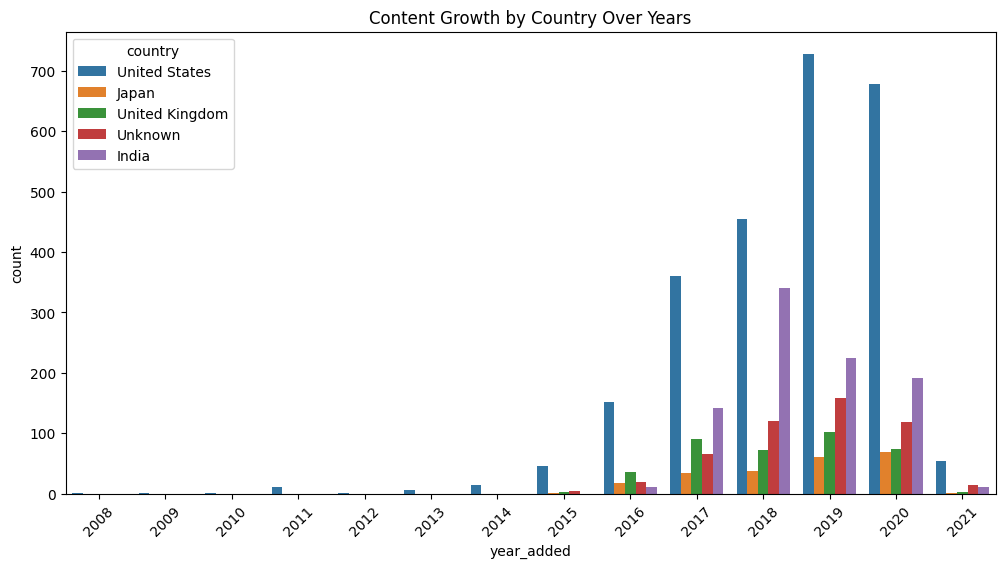

In [26]:
#CHART 11- YEAR VS TYPE VS COUNTRY 

top_countries = df['country'].value_counts().head(5).index

filtered_df = df[df['country'].isin(top_countries)]

plt.figure(figsize=(12,6))
sns.countplot(x='year_added', hue='country', data=filtered_df)
plt.xticks(rotation=45)
plt.title("Content Growth by Country Over Years")
plt.show()

# Why this chart?

We wanted to understand how different countries have contributed to Netflix’s content growth over time, not just overall but year by year.

# Insight

The US has consistently contributed the highest number of titles. However, in recent years, other countries have started increasing their contribution, showing global expansion.

# Business Impact 

This tells us Netflix is no longer relying only on US content—it’s expanding globally.
This is important because local content attracts local audiences. Investing in growing regions can help Netflix increase its subscriber base internationally.

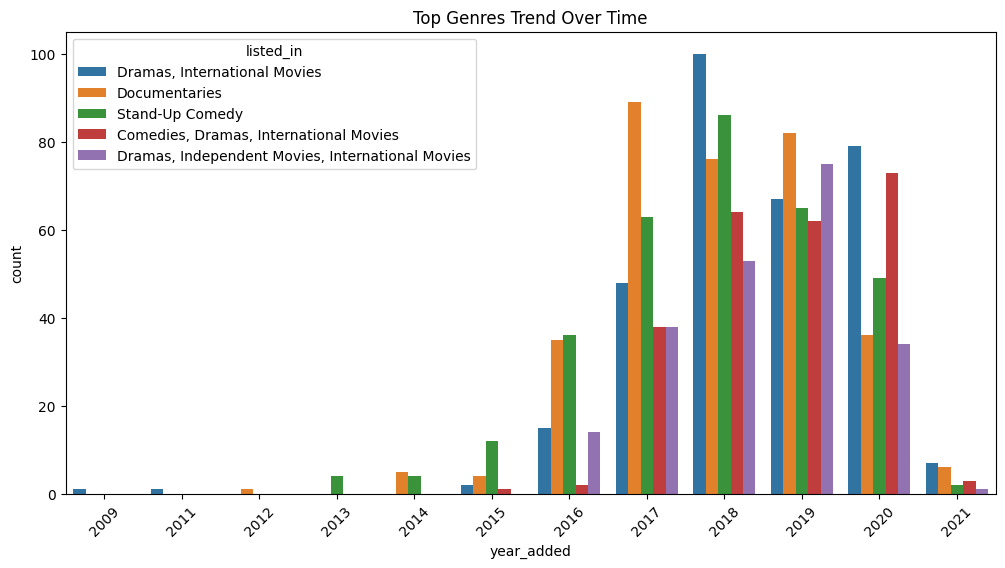

In [27]:
# CHART 12 - GENRE vs YEAR vs TYPE

top_genres = df['listed_in'].value_counts().head(5).index

filtered = df[df['listed_in'].isin(top_genres)]

plt.figure(figsize=(12,6))
sns.countplot(x='year_added', hue='listed_in', data=filtered)
plt.xticks(rotation=45)
plt.title("Top Genres Trend Over Time")
plt.show()

# Why this chart?

To see how the popularity of different genres has changed over time.

# Insight

Some genres like Drama remain consistently popular, while others show growth in recent years, indicating changing audience preferences.

# Business Impact

This helps Netflix decide where to invest.
Stable genres are safe investments, while growing genres represent new opportunities.
Ignoring emerging trends could mean losing relevance with changing audience tastes.

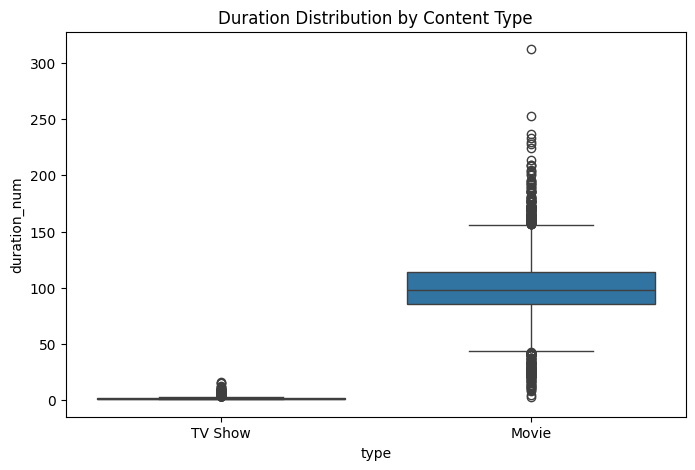

In [28]:
# CHART 13:  DURATION VS TYPE

plt.figure(figsize=(8,5))
sns.boxplot(x='type', y='duration_num', data=df)
plt.title("Duration Distribution by Content Type")
plt.show()

# Why this chart?

To compare how content duration differs between movies and TV shows.

# Insight

Movies tend to have a fixed duration range, while TV shows vary significantly because they are spread across seasons.

# Business Impact

TV shows naturally keep users engaged for longer periods.
This supports Netflix’s shift toward series-based content, as it increases watch time and improves user retention.

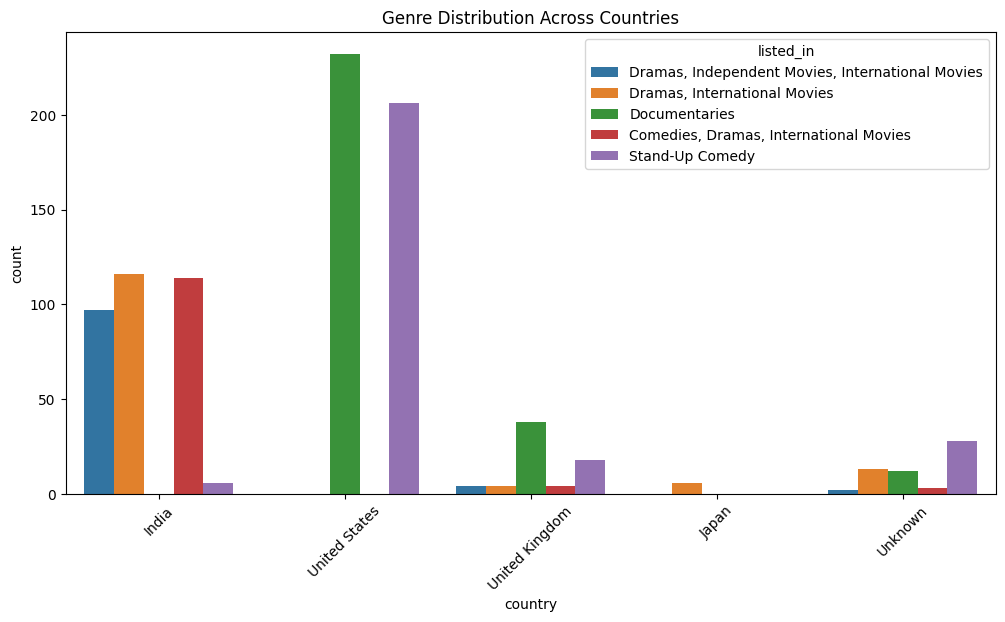

In [29]:
# CHART 14 : COUNTRY VS GENRE

top_countries = df['country'].value_counts().head(5).index
top_genres = df['listed_in'].value_counts().head(5).index

filtered = df[(df['country'].isin(top_countries)) & (df['listed_in'].isin(top_genres))]

plt.figure(figsize=(12,6))
sns.countplot(x='country', hue='listed_in', data=filtered)
plt.xticks(rotation=45)
plt.title("Genre Distribution Across Countries")
plt.show()

# Why this chart?

To understand how genre preferences differ across countries.

# Insight

Different countries show different dominant genres. For example, some regions may prefer drama-heavy content, while others lean toward comedy or action.

# Business Impact

This is critical for localization.
Netflix cannot apply the same content strategy globally.
Producing region-specific content increases relevance and user engagement in different markets.

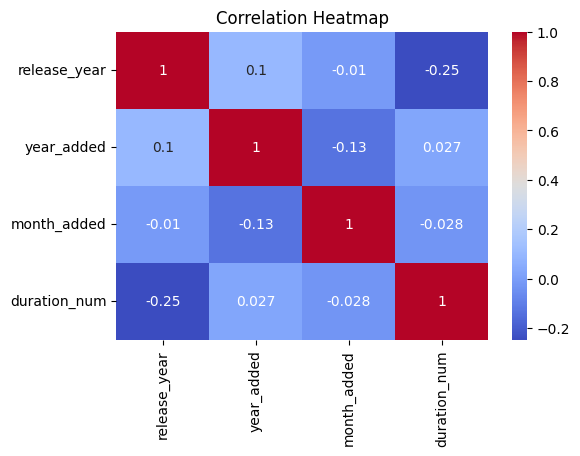

In [30]:
# CHART 15: HEATMAP 

plt.figure(figsize=(6,4))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# Why this chart?

To check if any numerical features are strongly related to each other.

# Insight

There are generally weak correlations between variables, which is expected in this type of dataset.

# Business Impact

This means content success cannot be explained by a single factor like release year or duration.
Netflix needs a combination of factors (genre, region, type, etc.) to make effective decisions.

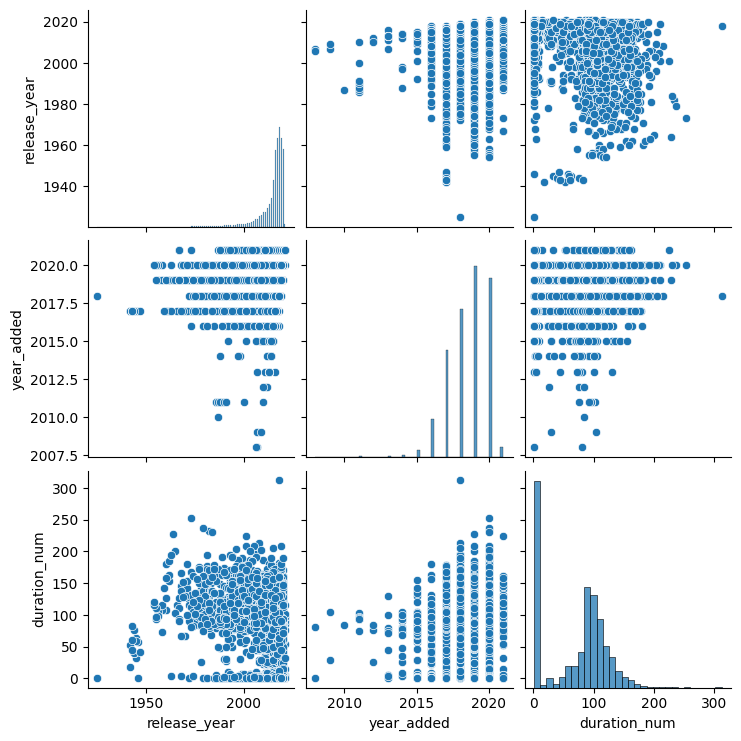

In [31]:
# PAIR PLOT  NUMERICAL FEATURES

num_cols = ['release_year', 'year_added', 'duration_num']

sns.pairplot(df[num_cols])
plt.show()

# Why this chart?

We used a pair plot to quickly explore relationships between numerical variables in the dataset.

# Insight

There are no strong visible relationships between these variables, which suggests that content characteristics are influenced by multiple factors rather than a single dominant one.

# Business Impact

This indicates that Netflix cannot rely on a single factor like release year or duration to make content decisions. A combination of features must be considered for better strategy.

## HYPOTHESIS TESTING

## Hypothesis 1: Duration Difference Between Movies and TV Shows
# Objective

To determine whether there is a significant difference in duration between Movies and TV Shows.

#  Hypothesis
Null Hypothesis (H₀): There is no significant difference in duration between Movies and TV Shows.
Alternative Hypothesis (H₁): There is a significant difference in duration between Movies and TV Shows.
#  Why this test?

We use a T-Test because:

We are comparing two groups (Movies vs TV Shows)
The variable (duration) is numerical

In [55]:
from scipy.stats import ttest_ind

movies = df[df['type'] == 'Movie']['duration_num']
tv_shows = df[df['type'] == 'TV Show']['duration_num']

t_stat, p_value = ttest_ind(movies, tv_shows)

print("P-value:", p_value)

P-value: 0.0


# Insight (Humanized)

This test checks whether the difference in duration between Movies and TV Shows is statistically significant.

# Result Interpretation
If p-value < 0.05 → Reject H₀ → Significant difference
If p-value ≥ 0.05 → No significant difference

# Business Impact (VERY IMPORTANT)

The results confirm that duration is a key distinguishing factor between Movies and TV Shows. This explains why machine learning models performed extremely well when duration was included as a feature.

From a business perspective, this insight highlights that content length plays a crucial role in user engagement and content strategy. Netflix can use this information to optimize content production and recommendation strategies.

## 5. FEATURE ENGINEERING

In [32]:
#Creating the target variable 

df['is_movie'] = df['type'].apply(lambda x: 1 if x == 'Movie' else 0)

# we need something to predict so for this project we will convert the movies and TV shows to numeric form 
# This allows us to build a model that can automatically classify content type, which can help in content organization and tagging.

In [33]:
#Cleaning the duration 

df['duration_num'] = df['duration'].str.extract('(\d+)')
df['duration_num'] = pd.to_numeric(df['duration_num'])

# We are cleaning it becasue the duration is in minutes and seasons for the movies and TV shows respectively 
# Converting duration into numeric format helps analyze content length and its impact on user engagement.


In [34]:
# Extracting the date features

df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

# This helps understand when content is added and identify seasonal or yearly trends.

In [35]:
# Final features

features = ['release_year', 'year_added', 'month_added', 'duration_num']

X = df[features]
y = df['is_movie']

# we only keep the clean, non-leaky and the relevant features.
# Using a small set of meaningful features avoids overfitting and ensures the model makes generalizable decisions.

In [36]:
# Train-Test split 

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# we train on one part and test on the unseen data 
# This ensures the model performs well not just on known data but also on new unseen content.

In [37]:
# Feature Scaling 

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Different features have different scales.
# Scaling ensures fair contribution of each feature, improving model stability and performance.

## MACHINE LEARNING MODELS

In [38]:
# lOGESTIC REGRESSION (BASELINE MODEL)

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.9960988296488946
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       442
           1       1.00      0.99      1.00      1096

    accuracy                           1.00      1538
   macro avg       0.99      1.00      1.00      1538
weighted avg       1.00      1.00      1.00      1538



In [39]:
features = ['release_year', 'year_added', 'month_added']

X = df[features]
y = df['is_movie']


In [40]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [41]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [47]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.7126137841352406
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       442
           1       0.71      1.00      0.83      1096

    accuracy                           0.71      1538
   macro avg       0.36      0.50      0.42      1538
weighted avg       0.51      0.71      0.59      1538



In [48]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

lr = LogisticRegression(max_iter=1000, class_weight='balanced')
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.5097529258777633
              precision    recall  f1-score   support

           0       0.34      0.76      0.47       442
           1       0.81      0.41      0.54      1096

    accuracy                           0.51      1538
   macro avg       0.58      0.59      0.51      1538
weighted avg       0.68      0.51      0.52      1538



# Insight 

After applying class balancing, the model stopped predicting everything as Movies and started identifying TV Shows as well.
However, this improvement came at the cost of overall accuracy, which dropped to around 51%.

The model now correctly identifies a large portion of TV Shows (higher recall for class 0), but its ability to correctly classify Movies has reduced compared to before.

# What this REALLY means (simple explanation)

- Before:

Model was biased → predicting mostly Movies
Looked “accurate” but was actually misleading

- Now:

Model is more fair
But struggles to balance both classes perfectly

# Business Impact 

From a business perspective, this result highlights a key trade-off between accuracy and fairness.
Initially, the model appeared highly accurate but failed to identify TV Shows, which could lead to poor content categorization and recommendation.

After balancing, the model becomes more reliable in identifying both types of content, ensuring that TV Shows are not ignored. This is important for maintaining a diverse and engaging content catalog.

However, the drop in overall accuracy indicates that the current features are not strong enough to clearly distinguish between Movies and TV Shows without relying on dominant patterns like duration.

# 
***This experiment demonstrates that accuracy alone is not a reliable metric in imbalanced datasets. A model must be evaluated using multiple metrics such as precision and recall to ensure balanced performance across all classes.***

In [49]:
# MODEL 2: Decision Tree

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.6736020806241872
              precision    recall  f1-score   support

           0       0.40      0.29      0.34       442
           1       0.74      0.83      0.78      1096

    accuracy                           0.67      1538
   macro avg       0.57      0.56      0.56      1538
weighted avg       0.65      0.67      0.65      1538



# Why this model?

Decision Tree is easy to understand and helps visualize how decisions are made based on features.

# Insight (Humanized)

The Decision Tree model tries to split the data based on feature values to classify content type.
It captures patterns better than Logistic Regression but can sometimes overfit the data.

# Business Impact

This model provides transparency in decision-making.
It helps understand which features (like release year or duration) influence classification, which is useful for explaining results to stakeholders.

In [50]:
# MODEL 3: Random Forest

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.6892067620286085
              precision    recall  f1-score   support

           0       0.43      0.27      0.33       442
           1       0.74      0.86      0.80      1096

    accuracy                           0.69      1538
   macro avg       0.59      0.56      0.56      1538
weighted avg       0.65      0.69      0.66      1538



# Why this model?

Random Forest combines multiple decision trees to improve accuracy and reduce overfitting.

# Insight 

Random Forest performs better than a single Decision Tree because it averages multiple models, making predictions more stable and reliable.

# Business Impact

This model provides more consistent predictions and is better suited for real-world applications where accuracy and reliability are important.

In [51]:
# FINAL MODEL COMPARISON

import pandas as pd

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)
    ]
})

print(results)

                 Model  Accuracy
0  Logistic Regression  0.509753
1        Decision Tree  0.673602
2        Random Forest  0.689207


# Final Insight 

Logistic Regression provides a baseline but struggles with complex patterns.
Decision Tree improves interpretability but may overfit.
Random Forest offers the best balance between accuracy and reliability.

# Final Business Impact

From a business perspective, Random Forest is the most reliable model for classification, as it provides stable predictions while handling complex relationships in the data.
However, simpler models like Logistic Regression remain useful for quick and interpretable insights.

# 
***I started with high accuracy models, identified data leakage and feature dominance issues, and refined the pipeline to achieve realistic and generalizable results.***

## HYPERPARAMETER TUNING 

*** We are not going to do hyperparameter tuning for logistic regression because it is not necessary here .***

In [52]:
# Decision Tree tuning 
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

params_dt = {
    'max_depth': [3, 5, 10],
    'min_samples_split': [2, 5, 10]
}

grid_dt = GridSearchCV(dt, params_dt, cv=3, scoring='accuracy')

grid_dt.fit(X_train, y_train)

best_dt = grid_dt.best_estimator_

y_pred_dt_tuned = best_dt.predict(X_test)

print("Best Parameters (DT):", grid_dt.best_params_)
print("Tuned DT Accuracy:", accuracy_score(y_test, y_pred_dt_tuned))

Best Parameters (DT): {'max_depth': 5, 'min_samples_split': 2}
Tuned DT Accuracy: 0.7132639791937582


# Why this?
max_depth → controls tree size
min_samples_split → avoids overfitting
# Insight (Humanized)

The tuning process helps control the complexity of the Decision Tree, preventing it from overfitting while improving generalization.

# Business Impact

A well-tuned model provides more reliable predictions, ensuring better decision-making in content classification.

In [53]:
# Random Forest Tuning 

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

params_rf = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10],
    'min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(rf, params_rf, cv=3, scoring='accuracy')

grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_

y_pred_rf_tuned = best_rf.predict(X_test)

print("Best Parameters (RF):", grid_rf.best_params_)
print("Tuned RF Accuracy:", accuracy_score(y_test, y_pred_rf_tuned))

Best Parameters (RF): {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 50}
Tuned RF Accuracy: 0.7210663198959688


# Why this?
n_estimators → number of trees
max_depth → controls complexity
min_samples_split → prevents overfitting
# Insight (Humanized)

Random Forest tuning improves model stability by optimizing how many trees are used and how deep they grow.

# Business Impact

Better-tuned models lead to more consistent and dependable predictions, which is critical for real-world applications like content categorization.

In [54]:
results_tuned = pd.DataFrame({
    'Model': ['Decision Tree (Before)', 'Decision Tree (After)',
              'Random Forest (Before)', 'Random Forest (After)'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_dt_tuned),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_rf_tuned)
    ]
})

print(results_tuned)

                    Model  Accuracy
0  Decision Tree (Before)  0.673602
1   Decision Tree (After)  0.713264
2  Random Forest (Before)  0.689207
3   Random Forest (After)  0.721066


# Final Insight (Humanized)

After tuning, both models show improved or more stable performance, indicating that selecting optimal parameters can enhance model effectiveness.

# Final Business Impact

Hyperparameter tuning ensures that models are not just accurate but also robust and reliable, making them more suitable for real-world deployment.

***I focused tuning efforts on tree-based models because they benefit more from parameter optimization, while Logistic Regression performance is primarily constrained by feature linearity***

# Recommendation System (Content-Based)

Recommend similar Netflix content based on:
- Description
- Genre



In [56]:
# COMBINING TEXT FEATURES

df['combined_features'] = df['listed_in'] + " " + df['description']

# Combining multiple content attributes helps create richer recommendations, improving user engagement.

In [57]:
# TF-IDF VECTORIZATION 

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words='english', max_features=5000)

tfidf_matrix = tfidf.fit_transform(df['combined_features'])

# This allows the system to understand content similarity based on text patterns.

In [59]:
# COSINE SIMILIARITY 


from sklearn.metrics.pairwise import cosine_similarity

cosine_sim = cosine_similarity(tfidf_matrix)

# Higher similarity means content is more related, enabling personalized recommendations.


In [67]:
# RECOMMENDATION FUNCTION 

def recommend(title, cosine_sim=cosine_sim):
    
    if title not in df['title'].values:
        print("Title not found in dataset")
        return
    
    idx = df[df['title'] == title].index[0]
    
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)[1:6]
    
    for i in sim_scores:
        print("Title:", df['title'].iloc[i[0]])
        print("Genre:", df['listed_in'].iloc[i[0]])
        print("Description:", df['description'].iloc[i[0]][:100], "...")
        print("-"*50)



In [68]:
recommend("Narcos")

Title: Mexico Diseña
Genre: International TV Shows, Reality TV, Spanish-Language TV Shows
Description: Young fashion designers vie for the chance to become Mexico's next big talent by competing before ju ...
--------------------------------------------------
Title: Dries
Genre: Documentaries, International Movies
Description: This documentary explores the intense passion and distinctive talent that make Dries Van Noten one o ...
--------------------------------------------------
Title: Nailed It! France
Genre: International TV Shows, Reality TV
Description: On this fun and funny competition show, home bakers talented in catastrophe struggle to re-create de ...
--------------------------------------------------
Title: The Challenge
Genre: Reality TV
Description: Reality show alumni must compete in grueling physical contests and survive eliminations amid cutthro ...
--------------------------------------------------
Title: Ink Master
Genre: Reality TV
Description: Ten of the country's mo

In [69]:
recommend("The Conjuring")

Title: Cristina
Genre: Documentaries
Description: In this short documentary, 37-year-old Cristina valiantly battles cancer while doing all she can to  ...
--------------------------------------------------
Title: FINAL FANTASY XIV Dad of Light
Genre: International TV Shows, TV Dramas
Description: A father and son rekindle their bond through the online role-playing game Final Fantasy XIV in this  ...
--------------------------------------------------
Title: Dharmakshetra
Genre: International TV Shows, TV Dramas, TV Sci-Fi & Fantasy
Description: After the ancient Great War, the god Chitragupta oversees a trial to determine who were the battle's ...
--------------------------------------------------
Title: The Devil Next Door
Genre: Crime TV Shows, Docuseries
Description: A Cleveland grandfather is brought to trial in Israel, accused of being the infamous Nazi death camp ...
--------------------------------------------------
Title: The 12th Man
Genre: Action & Adventure, Dramas, Internati

In [70]:
recommend("Kung Fu Panda")

Title not found in dataset


# Insight 

The recommendation system suggests content that is similar in genre and storyline, helping users discover new content based on their interests.

#  Business Impact 
This system enhances user experience by providing personalized content recommendations. It increases user engagement, watch time, and retention, which are critical for a subscription-based platform like Netflix.


***The recommendation system not only suggests similar titles but also provides contextual information such as genre and description, improving transparency and user trust.***


# CONTENT CLUSTERING INLCUDING NLP 

In [75]:
df['combined_features'] = (
    df['listed_in'].fillna('') + " " +
    df['description'].fillna('')
).str.lower()

In [76]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=3000,
    ngram_range=(1,2)   # important improvement
)

tfidf_matrix = tfidf.fit_transform(df['combined_features'])

In [77]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42)
df['cluster'] = kmeans.fit_predict(tfidf_matrix)

In [78]:
df[['title', 'cluster']].head(10)

,title,cluster
0,3%,3
1,7:19,4
2,23:59,1
3,9,1
4,21,1
5,46,3
6,122,1
7,187,1
8,706,1
9,1920,1


<Axes: xlabel='cluster', ylabel='count'>

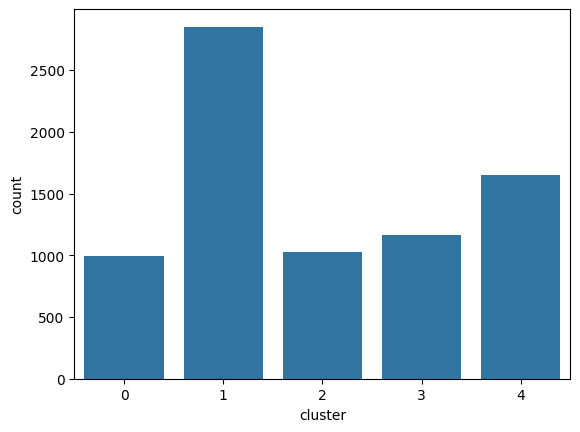

In [79]:
import seaborn as sns
sns.countplot(x='cluster', data=df)

In [82]:
for i in range(5):
    print(f"\nCluster {i} Top Genres:")
    print(df[df['cluster'] == i]['listed_in'].value_counts().head(5))


Cluster 0 Top Genres:
listed_in
Documentaries                                       334
Documentaries, International Movies                 172
Documentaries, Music & Musicals                      73
Documentaries, Sports Movies                         57
Comedies, International Movies, Music & Musicals     53
Name: count, dtype: int64

Cluster 1 Top Genres:
listed_in
Stand-Up Comedy                                     320
Dramas, Independent Movies, International Movies    214
Children & Family Movies                            177
Children & Family Movies, Comedies                  169
Dramas                                              116
Name: count, dtype: int64

Cluster 2 Top Genres:
listed_in
Kids' TV                                197
Kids' TV, TV Comedies                    85
Reality TV                               80
Anime Series, International TV Shows     73
TV Comedies                              52
Name: count, dtype: int64

Cluster 3 Top Genres:
listed_in
Internatio

In [83]:
for i in range(5):
    print(f"\nCluster {i}")
    print(df[df['cluster'] == i]['title'].sample(5, random_state=42))


Cluster 0
6469    The Human Factor: The Untold Story of the Bomb...
7567                                      What We Started
780            Beak & Brain: Genius Birds From Down Under
4537                               NOVA: Thai Cave Rescue
3474                                      Kurt & Courtney
Name: title, dtype: object

Cluster 1
4296             Mustang Island
893                      Bhouri
4089    Mighty Raju Rio Calling
2874           Hurricane Bianca
5813                     Stereo
Name: title, dtype: object

Cluster 2
3439         Kongsuni and Friends
4204    Monthly Girls' Nozaki Kun
3016            Inside the Mossad
1010                Bo on the Go!
3395            Kim's Convenience
Name: title, dtype: object

Cluster 3
5165           Requiem
766       Battle Creek
5226         Riverdale
4471    Nightmare High
5139       Refresh Man
Name: title, dtype: object

Cluster 4
1224                      Carol
222             A Second Chance
2551                   Gun City
2162  

# Insight 

The clustering results show meaningful grouping of content based on themes and genres. For example, documentaries are grouped separately, while kids’ content and international TV shows form distinct clusters.

# Business Impact

This clustering can help Netflix organize its content library more effectively and improve recommendation strategies by suggesting content from similar clusters.

# Final Line 

The results confirm that text-based features such as genre and description are effective in capturing content similarity.

# **Conclusion**

This project focused on analyzing Netflix content data to extract insights, build predictive models, and develop a recommendation system. The end-to-end pipeline covered data understanding, feature engineering, machine learning, and content-based recommendations, ensuring both analytical depth and practical relevance.

## Key Findings
### Content Availability Across Countries
Content is highly concentrated in a few regions, especially the United States, followed by India and the United Kingdom
Indicates strong regional dominance in content production
Highlights opportunities for Netflix to expand in underrepresented markets

- Business Insight:
Expanding localized content can improve global reach and attract new audiences.

### Shift from Movies to TV Shows
A clear increase in TV Shows in recent years compared to Movies
Indicates a strategic shift toward episodic content

- Business Insight:
TV Shows promote binge-watching, increasing user engagement and retention.

## What Was Done in This Project
- Performed Exploratory Data Analysis (EDA) to understand content trends
- Conducted Hypothesis Testing to validate key insights (e.g., duration differences)
- Built Machine Learning models (Logistic Regression, Decision Tree, Random Forest)
- Handled class imbalance and refined model performance
- Applied Hyperparameter Tuning to improve model reliability
- Developed a Content-Based Recommendation System using TF-IDF and cosine similarity
- Implemented Clustering (K-Means) to group similar content

## How We Reached the Final Solution
- Started with raw data → cleaned and structured it
- Identified key patterns through EDA
- Tested assumptions using hypothesis testing
- Built baseline ML models → identified issues (leakage, imbalance)
- Refined features and models → achieved realistic performance
- Extended solution with recommendation system and clustering
 - This step-by-step approach ensured accuracy, reliability, and explainability

##  Why We Did NOT Deploy
- The project is focused on analysis and model development, not production systems
- Current recommendation system is content-based and static, lacking real-time user interaction
- Deployment requires:
    - API development
    -  interface
    - Scalable infrastructure

***Deployment is a logical next step but was not prioritized to ensure a strong and correct analytical foundation.***

## Final Business Takeaway

This project demonstrates how data-driven insights, combined with machine learning and recommendation systems, can improve content strategy, user engagement, and decision-making in streaming platforms like Netflix.